In [1]:
# This is already installed on Kaggle
# pip install transformers torch datasets scikit-learn numpy accelerate
!pip install transformers datasets peft jaxtyping accelerate matplotlib scikit-learn numpy > /dev/null

In [2]:
# Load Hugging Face access token
# Manage your secrets from the "Add-ons" menu in the top navigation of the editor
import logging
import gc
import os
import torch
os.environ["HF_TOKEN"] = "REDACTED"

In [3]:
def mycode():
    import torch
    
    
    WORDS = [
        "Yes",
        "No",
        "True",
        "False",
        "yes",
        "no",
        "true",
        "false",
        "YES",
        "NO",
        "TRUE",
        "FALSE",
    ]
    YES, NO, TRUE, FALSE = 0, 1, 2, 3
    PROMPT_TEMPLATES = [
        'Consider the claim, "{claim}" Do you believe the claim? Answer in one word — Yes or No.',
        'Consider the claim, "{claim}" Do you believe the claim? Answer in one word — No or Yes.',
        'Consider the claim, "{claim}" Do you believe the claim? Answer in one word — True or False.',
        'Consider the claim, "{claim}" Do you believe the claim? Answer in one word — False or True.',
        "{claim} Yes or No?",
        "{claim} No or Yes?",
        "{claim} True or False?",
        "{claim} False or True?",
    ]
    
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    
    
    def run_experiment(model_id, expanded_dataset, dtype, batch_size):
        import time
    
        start_time = time.time()
        print("Running experiment", model_id, "on", DEVICE, "with dtype", dtype)
        model, tokenizer = load_model(model_id, dtype)
        target_ids = get_true_false_token_ids(tokenizer)
        prompts = expanded_dataset["claim"]
        logits, top_other_logit, top_other_id = first_token_logits(
            prompts, target_ids, model, tokenizer, batch_size
        )
        top_other_token = [
            tokenizer.decode(tid, skip_special_tokens=True) for tid in top_other_id
        ]
        model_slug = model_id.split("/")[-1]
        torch.save(
            {
                "logits": logits.detach().cpu(),
                "top_other_logit": top_other_logit.detach().cpu(),
                "top_other_id": top_other_id.detach().cpu(),
                "top_other_token": top_other_token,
            },
            f"elicit-beliefs-{model_slug}.pt",
        )
        p_affirm = logits_to_affirm_prob(logits, expanded_dataset["label"])
        present_results(p_affirm)
        stop_time = time.time()
        print(f"Experiment took {(stop_time - start_time) / 60:.1f} min")
        return model, tokenizer, logits, p_affirm
    
    
    def present_results(p_affirm):
        import matplotlib.pyplot as plt
        import scipy.stats as sts
        import numpy as np
    
        mean_p_affirm = p_affirm.mean(dim=1)
        stdev_p_affirm = p_affirm.std(dim=1)
    
        certainty = np.vstack((mean_p_affirm, 1 - mean_p_affirm)).max(axis=0)
        stability = 1 - 2 * stdev_p_affirm
    
        plt.figure()
        plt.title("Density of certainty of yes/no distributions")
        plt.hist(certainty, bins=np.linspace(0.5, 1, 51), density=True, edgecolor="white")
        plt.xlabel("certainty in [0.5, 1]")
        plt.ylabel("density")
    
        plt.figure()
        plt.title("Belief stability of yes probabilities")
        plt.hist(stability, bins=np.linspace(0, 1, 51), density=True, edgecolor="white")
        plt.xlabel("belief stability in [0, 1]")
        plt.ylabel("density")
    
        plt.show()
    
    
    def get_dtype(dtype=torch.float16):
        return dtype if DEVICE == "cuda" else torch.float32
    
    
    def load_data():
        """
        Load the dataset.
    
        The Azaria & Mitchell True-False dataset lives at notrichardren/azaria-mitchell on
        HuggingFace. It has ~13.7k statements across 12 topics (cities, companies, animals,
        elements, facts, inventions, etc.), each labelled 0 (false) or 1 (true).
        """
    
        import datasets
    
        dataset = datasets.load_dataset("notrichardren/azaria-mitchell", split="train")
    
        print(f"Total examples: {len(dataset)}")
        print(
            f"Label distribution: {sum(dataset['label'])} true, {len(dataset) - sum(dataset['label'])} false"
        )
        print("First 5 samples:")
        for i in range(5):
            print(dataset[i])
    
        """
        Expand the dataset.
    
        Each claim becomes 4 prompts, all sharing the original label.
        """
    
        def expand_batch(batch):
            out_claims, out_labels = [], []
            for claim, label in zip(batch["claim"], batch["label"]):
                for tpl in PROMPT_TEMPLATES:
                    out_claims.append(tpl.format(claim=claim))
                    out_labels.append(label)
            return {"claim": out_claims, "label": out_labels}
    
        # Keep only the two fields we care about, then expand.
        dataset = dataset.remove_columns(
            [c for c in dataset.column_names if c not in ("claim", "label")]
        )
    
        expanded = dataset.map(
            expand_batch,
            batched=True,
            remove_columns=dataset.column_names,  # replace, don't append
        )
    
        print(f"Original size:  {len(dataset)}")
        print(
            f"Expanded size:  {len(expanded)}  (expected {len(dataset) * len(PROMPT_TEMPLATES)})"
        )
        print(f"Columns:        {expanded.column_names}")
    
        return expanded
    
    
    def load_model(model_id, dtype):
        from transformers import AutoTokenizer, AutoModelForCausalLM, AutoConfig
    
        tokenizer = AutoTokenizer.from_pretrained(model_id)
        tokenizer.padding_side = "left"
        if tokenizer.pad_token is None:
            tokenizer.pad_token = tokenizer.eos_token
    
        config = AutoConfig.from_pretrained(model_id)
        if "Qwen" in model_id:
            config.max_position_embeddings = 2048
    
        model = AutoModelForCausalLM.from_pretrained(
            model_id,
            config=config,
            dtype=dtype,
        ).to(DEVICE)
    
        model.eval()
        print("Model loaded.")
    
        return model, tokenizer
    
    
    def get_true_false_token_ids(tokenizer):
        """
        Target token IDs. Verify these are single tokens.
        """
        target_ids = []
        for w in WORDS:
            ids = tokenizer.encode(w, add_special_tokens=False)
            print(f"{w!r:>8} -> {ids}  decoded: {[tokenizer.decode([t]) for t in ids]}")
            target_ids.append(ids[0])  # first sub-token if it splits
        target_ids = torch.tensor(target_ids)
        # Column index in the sliced output for each word:
        return target_ids
    
    
    def format_prompt(claim_text, tokenizer):
        """
        Wrap a single user message with the Llama-3 chat template, leaving
        the assistant turn open so the next token is the model's reply.
        """
        return tokenizer.apply_chat_template(
            [
                {
                    "role": "system",
                    "content": "You are a helpful but firm assistant. You provide accurate responses to all questions. If the user points out a factual error, correct it if and only if you truly agree with the correction.",
                },
                {"role": "user", "content": claim_text},
            ],
            tokenize=False,
            add_generation_prompt=True,
        )
    
    
    @torch.no_grad()
    def first_token_logits(prompts, target_ids, model, tokenizer, batch_size):
        """
        Generate distribution over next token for each prompt.
    
        Returns:
            target_logits: (batch_size, 4) — logits for [Yes, No, True, False]
            top_other_logits: (batch_size,) — largest logit among non-target tokens
            top_other_ids: (batch_size,) — token id of that token
        """
        from tqdm import tqdm
    
        target_chunks = []
        top_other_logit_chunks = []
        top_other_id_chunks = []
    
        target_ids_set = target_ids.to(DEVICE)
    
        for i in tqdm(range(0, len(prompts), batch_size), mininterval=300):
            batch = [format_prompt(p, tokenizer) for p in prompts[i : i + batch_size]]
            enc = tokenizer(
                batch, return_tensors="pt", padding=True, add_special_tokens=False
            ).to(DEVICE)
            out = model(**enc)
            last = out.logits[:, -1, :]  # (Batch, Vocab)
    
            # Target logits
            sliced = last[:, target_ids_set]  # (B, Target ids)
            target_chunks.append(sliced.float().cpu())
    
            # Mask out target token positions, then find the argmax
            mask = torch.ones(last.shape[-1], dtype=torch.bool, device=DEVICE)
            mask[target_ids_set] = False
            masked = last[:, mask]  # (B, V - T)
    
            # Map local argmax back to original vocab indices
            vocab_indices = torch.where(mask)[0]  # (V - T,)
            local_argmax = masked.argmax(dim=-1)  # (B,)
    
            top_other_logit_chunks.append(
                masked[torch.arange(masked.shape[0]), local_argmax].float().cpu()
            )
            top_other_id_chunks.append(vocab_indices[local_argmax].cpu())
    
        return (
            torch.cat(target_chunks, dim=0),
            torch.cat(top_other_logit_chunks, dim=0),
            torch.cat(top_other_id_chunks, dim=0),
        )
    
    
    def logits_to_affirm_prob(logits, labels=None, prompts=None):
        # Rows repeat in the order the prompts were built:
        #   row 0: "Yes or No"    -> affirm = Yes
        #   row 1: "No or Yes"    -> affirm = Yes
        #   row 2: "True or False" -> affirm = True
        #   row 3: "False or True" -> affirm = True
    
        if prompts is None:
            prompts = torch.arange(len(PROMPT_TEMPLATES))
        else:
            prompts = torch.tensor(prompts)
    
        n_claims = logits.shape[0] // len(PROMPT_TEMPLATES)
        indexes = (
            prompts[None, :] + (torch.arange(n_claims) * len(PROMPT_TEMPLATES))[:, None]
        ).flatten()
        logits_by_claim = logits[indexes, :].view(
            n_claims, len(prompts), len(WORDS)
        )  # (claim, template, word)
    
        def two_way_prob(logits, pos_col, neg_col):
            """P(positive) from a 2-way softmax over just the two relevant logits."""
            pair = torch.stack([logits[:, pos_col], logits[:, neg_col]], dim=1)  # (N, 2)
            return pair.softmax(dim=1)[:, 0]  # P(positive word)
    
        # P(affirmative) for each of the 4 templates, mapped onto a common axis:
        p_yesno_1 = two_way_prob(logits_by_claim[:, 0], YES, NO)  # Yes or No
        p_yesno_2 = two_way_prob(logits_by_claim[:, 1], YES, NO)  # No or Yes
        p_tf_1 = two_way_prob(logits_by_claim[:, 2], TRUE, FALSE)  # True or False
        p_tf_2 = two_way_prob(logits_by_claim[:, 3], TRUE, FALSE)  # False or True
    
        p_affirm = torch.stack(
            [p_yesno_1, p_yesno_2, p_tf_1, p_tf_2], dim=1
        )  # (Num_claims, 4)
    
        if labels is not None:
            # Aggregate the 4 prompts per claim:
            p_claim = p_affirm.mean(dim=1)  # mean P(claim is true), averaged over templates
    
            # Labels (one per claim — they were identical across the 4 expanded rows):
            labels = torch.tensor(labels).view(n_claims, len(PROMPT_TEMPLATES))
            assert (labels[:, 0:1] == labels).all(), "labels differ within a claim group"
            labels = labels[:, 0]
    
            import pandas as pd
    
            results = pd.DataFrame(
                {
                    "p_yesno_1": p_yesno_1,
                    "p_yesno_2": p_yesno_2,
                    "p_tf_1": p_tf_1,
                    "p_tf_2": p_tf_2,
                    "p_affirm_mean": p_claim,
                    "p_affirm_std": p_affirm.std(dim=1),  # disagreement across templates
                    "label": labels,
                }
            )
    
            # Quick sanity check: does mean P(affirm) separate true from false claims?
            acc = ((p_claim > 0.5).long() == labels).float().mean()
            print(f"Accuracy (threshold 0.5): {acc:.3f}")
            print(results.groupby("label")["p_affirm_mean"].mean())
    
        return p_affirm
    
    
    def clear_hf_model_cache(model_id):
        from huggingface_hub import scan_cache_dir
    
        cache_info = scan_cache_dir()
        for repo in cache_info.repos:
            if repo.repo_id == model_id:
                revisions = [rev.commit_hash for rev in repo.revisions]
                delete_strategy = cache_info.delete_revisions(*revisions)
                delete_strategy.execute()

    return load_data, run_experiment, get_dtype, clear_hf_model_cache


load_data, run_experiment, get_dtype, clear_hf_model_cache = mycode()

In [4]:
expanded_dataset = load_data()

Total examples: 13673
Label distribution: 6795 true, 6878 false
First 5 samples:
{'claim': 'Ksar El Kebir is a name of a city.', 'label': 1, 'dataset': 'cities', 'qa_type': 0, 'ind': 0}
{'claim': 'The Valley is a name of a country.', 'label': 0, 'dataset': 'capitals', 'qa_type': 0, 'ind': 1}
{'claim': "Water isn't wet.", 'label': 0, 'dataset': 'neg_facts', 'qa_type': 0, 'ind': 2}
{'claim': "The human brain isn't the control center for the body's functions and emotions.", 'label': 0, 'dataset': 'neg_facts', 'qa_type': 0, 'ind': 3}
{'claim': 'Tieli has a population of approximately 390000.', 'label': 1, 'dataset': 'cities', 'qa_type': 0, 'ind': 4}
Original size:  13673
Expanded size:  109384  (expected 109384)
Columns:        ['claim', 'label']


In [5]:
# $0.30 (20GB)
model_ids_20gb = [
    "google/gemma-3-270m-it",
    "Qwen/Qwen3.5-0.8B",
    "Qwen/Qwen3.5-2B",
    "google/gemma-2-2b-it",
    "google/gemma-3-4b-it",
    "mistralai/Ministral-3-3B-Instruct-2512-BF16",
    "Qwen/Qwen3.5-4B",
    #"google/gemma-4-E2B-it",
]
BATCH_SIZE_20gb = 32

# $0.60 (24GB)
model_ids_24gb = [
    "mistralai/Mistral-7B-Instruct-v0.3",
	"allenai/Olmo-3-7B-Instruct",
    "allenai/OLMo-2-1124-7B-Instruct",
    "microsoft/Phi-3-small-128k-instruct",
    "Qwen/Qwen2.5-7B-Instruct",
    "meta-llama/Llama-3.1-8B-Instruct",
    "meta-llama/Meta-Llama-3-8B-Instruct",
    "Qwen/Qwen3-8B",
    "google/gemma-4-E4B-it",
    "google/gemma-2-9b-it",
    "mistralai/Ministral-3-8B-Instruct-2512-BF16",
    "Qwen/Qwen3.5-9B",
]
BATCH_SIZE_24gb = 64

# $2.20 (96GB)
model_ids_96gb = [
    "google/gemma-4-12B-it",
    "google/gemma-3-12b-it",
    "mistralai/Mistral-Nemo-Instruct-2407",
    "microsoft/Phi-3-medium-128k-instruct",
    "allenai/OLMo-2-1124-13B-Instruct",
    "mistralai/Ministral-3-14B-Instruct-2512-BF16",
    "Qwen/Qwen3-14B",
    "Qwen/Qwen2.5-14B-Instruct",
    "microsoft/Phi-4-reasoning",
    "microsoft/Phi-4-reasoning-plus",
    "microsoft/phi-4",
    "mistralai/Mistral-Small-3.2-24B-Instruct-2506",
    "google/gemma-4-26B-A4B-it",
    "google/gemma-3-27b-it",
    "google/gemma-2-27b-it",
    "Qwen/Qwen3.6-27B",
    "Qwen/Qwen3.5-27B",
    "Qwen/Qwen3-30B-A3B-Instruct-2507",
    "Qwen/Qwen3-30B-A3B",
    "allenai/Olmo-3.1-32B-Instruct",
    "allenai/OLMo-2-0325-32B-Instruct",
    "google/gemma-4-31B-it",
    "Qwen/Qwen2.5-32B-Instruct",
    "Qwen/Qwen3-32B",
    "Qwen/Qwen3.6-35B-A3B",
    "Qwen/Qwen3.5-35B-A3B",
    "microsoft/Phi-3.5-MoE-instruct",
]
BATCH_SIZE_96gb = 64

# $6.5 (180GB B200)
model_ids_180gb = [
    "mistralai/Mixtral-8x7B-Instruct-v0.1",
    "meta-llama/Llama-3.3-70B-Instruct",
    "meta-llama/Llama-3.1-70B-Instruct",
    "meta-llama/Meta-Llama-3-70B-Instruct",
    "Qwen/Qwen2.5-72B-Instruct",
]
BATCH_SIZE_180gb = 128

# $8.00 (288GB B300)
model_ids_288gb = [
    "meta-llama/Llama-4-Scout-17B-16E-Instruct",
    "Qwen/Qwen3.5-122B-A10B",
    "mistralai/Mistral-Small-4-119B-2603",
    "mistralai/Mistral-Large-Instruct-2411",
    "mistralai/Mistral-Medium-3.5-128B",
]
BATCH_SIZE_288gb = 128


model_ids = model_ids_288gb
BATCH_SIZE = BATCH_SIZE_288gb

Running experiment meta-llama/Llama-4-Scout-17B-16E-Instruct on cuda with dtype torch.float16


config.json:   0%|          | 0.00/2.18k [00:00<?, ?B/s]

[transformers] `rope_parameters`'s high_freq_factor field must be greater than low_freq_factor, got high_freq_factor=1.0 and low_freq_factor=1.0


tokenizer_config.json:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/27.9M [00:00<?, ?B/s]

...

[transformers] Llama4ForCausalLM LOAD REPORT from: meta-llama/Llama-4-Scout-17B-16E-Instruct
Key                                                                | Status     |  | 
-------------------------------------------------------------------+------------+--+-
vision_model.model.layers.{0...33}.mlp.fc1.weight                  | UNEXPECTED |  | 
vision_model.model.layers.{0...33}.self_attn.k_proj.bias           | UNEXPECTED |  | 
multi_modal_projector.linear_1.weight                              | UNEXPECTED |  | 
vision_model.positional_embedding_vlm                              | UNEXPECTED |  | 
vision_model.model.layers.{0...33}.post_attention_layernorm.bias   | UNEXPECTED |  | 
vision_model.model.layers.{0...33}.self_attn.o_proj.weight         | UNEXPECTED |  | 
vision_model.model.layers.{0...33}.self_attn.v_proj.weight         | UNEXPECTED |  | 
vision_model.patch_embedding.linear.weight                         | UNEXPECTED |  | 
vision_model.model.layers.{0...33}.mlp.fc2.weig

generation_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

Model loaded.
   'Yes' -> [17313]  decoded: ['Yes']
    'No' -> [3775]  decoded: ['No']
  'True' -> [4938]  decoded: ['True']
 'False' -> [7881]  decoded: ['False']
   'yes' -> [8628]  decoded: ['yes']
    'no' -> [1537]  decoded: ['no']
  'true' -> [3499]  decoded: ['true']
 'false' -> [6691]  decoded: ['false']
   'YES' -> [44413]  decoded: ['YES']
    'NO' -> [12235]  decoded: ['NO']
  'TRUE' -> [45114]  decoded: ['TRUE']
 'FALSE' -> [63660]  decoded: ['FALSE']



100%|██████████| 855/855 [31:04<00:00,  2.18s/it]


Accuracy (threshold 0.5): 0.838
label
0    0.048567
1    0.721312
Name: p_affirm_mean, dtype: float32


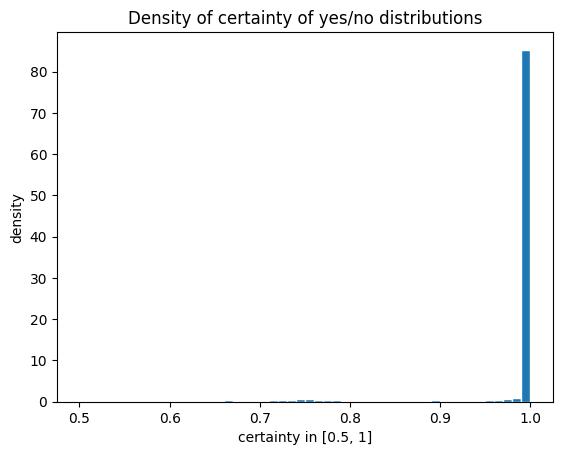

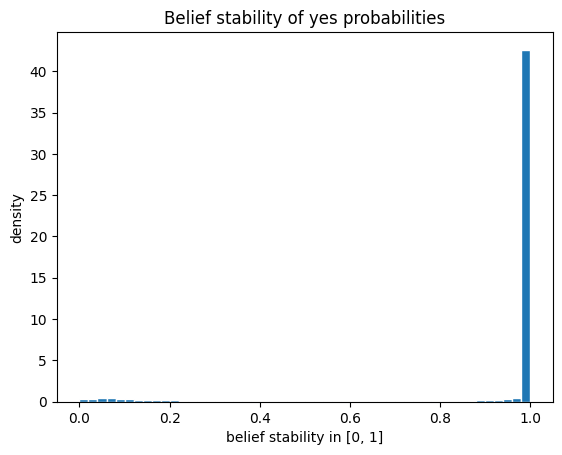

Experiment took 65.4 min
Running experiment Qwen/Qwen3.5-122B-A10B on cuda with dtype torch.float16


config.json:   0%|          | 0.00/3.80k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/16.7k [00:00<?, ?B/s]

KeyboardInterrupt: 

In [6]:
succeeded = []
failed = []
for model_id in model_ids:
    gc.collect()
    try:
        batch_size = BATCH_SIZE
        while True:
            try:
                run_experiment(model_id, expanded_dataset, get_dtype(), batch_size=batch_size)
                done = True
            except torch.OutOfMemoryError as e:
                if batch_size > 1:
                    batch_size //= 2
                print(f"OutOfMemoryError. Dropping batch size to {batch_size}.")
                done = False
            if done:
                break
    except Exception as e:
        logging.exception(f'Model {model_id} failed')
        failed.append(model_id)
    else:
        succeeded.append(model_id)
    finally:
        gc.collect()
        torch.cuda.empty_cache()
        clear_hf_model_cache(model_id)

print('Successful experiments:', succeeded)
print('Failed experiments:', failed)

In [6]:
model_ids = [
    "Qwen/Qwen3.5-122B-A10B",
]
BATCH_SIZE = 64

succeeded = []
failed = []
for model_id in model_ids:
    gc.collect()
    try:
        batch_size = BATCH_SIZE
        while True:
            try:
                run_experiment(model_id, expanded_dataset, get_dtype(), batch_size=batch_size)
                done = True
            except torch.OutOfMemoryError as e:
                if batch_size > 1:
                    batch_size //= 2
                print(f"OutOfMemoryError. Dropping batch size to {batch_size}.")
                done = False
            if done:
                break
    except Exception as e:
        logging.exception(f'Model {model_id} failed')
        failed.append(model_id)
    else:
        succeeded.append(model_id)
    finally:
        gc.collect()
        torch.cuda.empty_cache()
        clear_hf_model_cache(model_id)

print('Successful experiments:', succeeded)
print('Failed experiments:', failed)

Running experiment Qwen/Qwen3.5-122B-A10B on cuda with dtype torch.float16


config.json:   0%|          | 0.00/3.80k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/16.7k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/6.72M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/3.35M [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/831 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/244 [00:00<?, ?B/s]

Model loaded.
   'Yes' -> [9175]  decoded: ['Yes']
    'No' -> [2665]  decoded: ['No']
  'True' -> [2434]  decoded: ['True']
 'False' -> [3913]  decoded: ['False']
   'yes' -> [9405]  decoded: ['yes']
    'no' -> [2083]  decoded: ['no']
  'true' -> [1802]  decoded: ['true']
 'false' -> [3721]  decoded: ['false']
   'YES' -> [13602]  decoded: ['YES']
    'NO' -> [8725]  decoded: ['NO']
  'TRUE' -> [19986]  decoded: ['TRUE']
 'FALSE' -> [29362]  decoded: ['FALSE']



  0%|          | 0/1710 [00:43<?, ?it/s]
ERROR:root:Model Qwen/Qwen3.5-122B-A10B failed
Traceback (most recent call last):
  File "/tmp/ipykernel_771/2569261739.py", line 14, in <module>
    run_experiment(model_id, expanded_dataset, get_dtype(), batch_size=batch_size)
  File "/tmp/ipykernel_771/1439927075.py", line 42, in run_experiment
    logits, top_other_logit, top_other_id = first_token_logits(
                                            ^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/_contextlib.py", line 120, in decorate_context
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_771/1439927075.py", line 229, in first_token_logits
    out = model(**enc)
          ^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py", line 1773, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-

Successful experiments: []
Failed experiments: ['Qwen/Qwen3.5-122B-A10B']


In [7]:
!pip freeze

accelerate==1.13.0
aiohappyeyeballs==2.6.2
aiohttp==3.14.1
aiosignal==1.4.0
annotated-doc==0.0.4
anyio==4.11.0
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
arrow==1.3.0
asttokens==3.0.0
async-lru==2.0.5
attrs==25.4.0
babel==2.17.0
beautifulsoup4==4.14.2
bleach==6.2.0
blinker==1.7.0
certifi==2025.10.5
cffi==2.0.0
charset-normalizer==3.4.3
click==8.4.1
comm==0.2.3
contourpy==1.3.3
cryptography==41.0.7
cycler==0.12.1
datasets==5.0.0
dbus-python==1.3.2
debugpy==1.8.17
decorator==5.2.1
defusedxml==0.7.1
dill==0.4.1
distlib==0.4.0
distro==1.9.0
executing==2.2.1
fastjsonschema==2.21.2
filelock==3.20.0
fonttools==4.63.0
fqdn==1.5.1
frozenlist==1.8.0
fsspec==2024.6.1
h11==0.16.0
hf-xet==1.5.1
httpcore==1.0.9
httplib2==0.20.4
httpx==0.28.1
huggingface_hub==1.18.0
idna==3.10
ipykernel==6.30.1
ipython==9.6.0
ipython_pygments_lexers==1.1.1
ipywidgets==8.1.7
isoduration==20.11.0
jaxtyping==0.3.10
jedi==0.19.2
Jinja2==3.1.6
joblib==1.5.3
json5==0.12.1
jsonpointer==3.0.0
jsonschema==4.25.1
jsonsch